# T-cell episodic analysis

In [ ]:
# Dataset locations for this notebook come from ../datasets.yaml.
# Edit that file to point at your own copies -- do not hardcode paths below.
from focal.io import DatasetPaths

# DatasetPaths.find() walks up from the kernel's working directory to the first
# datasets.yaml (or uses $FOCAL_DATASETS), so it works wherever Jupyter was started.
config = DatasetPaths.find()


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import dictys
import joblib

In [2]:
from focal.temporal import *
from focal.utils import *

In [3]:
# Define file paths 
output_folder = config.TCELL_OUTPUT

### Inspect individual TFs

In [4]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file(os.path.join(output_folder, 'dynamic.h5'))

TCellExhaustion


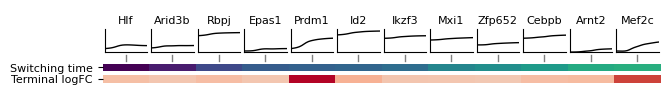

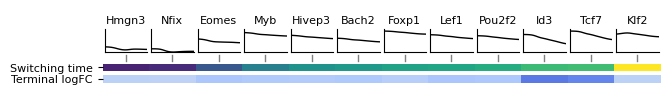

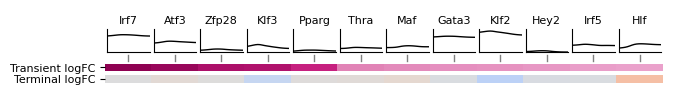

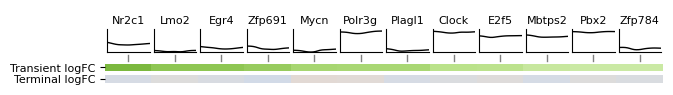

In [34]:
#Trajectory branch defined as (starting node, ending node) from trajectory inference
branches={
	'TCellExhaustion':(0,1)
}

for branchname in branches:
	print(branchname)
	figs=dictys_dynamic_object.draw_discover(*branches[branchname],ntops=(12,12,12,12),num=20,dist=0.001,mode='TF_expression')
	plt.show()

In [30]:
exp_curves_dy, exp_curves_dx = SmoothedCurvesGRN(dictys_dynamic_object,
    trajectory_range=(0,1),
    num_points=40,
    dist=0.002,
    sparsity=0.01,
    mode="expression").get_smoothed_curves()

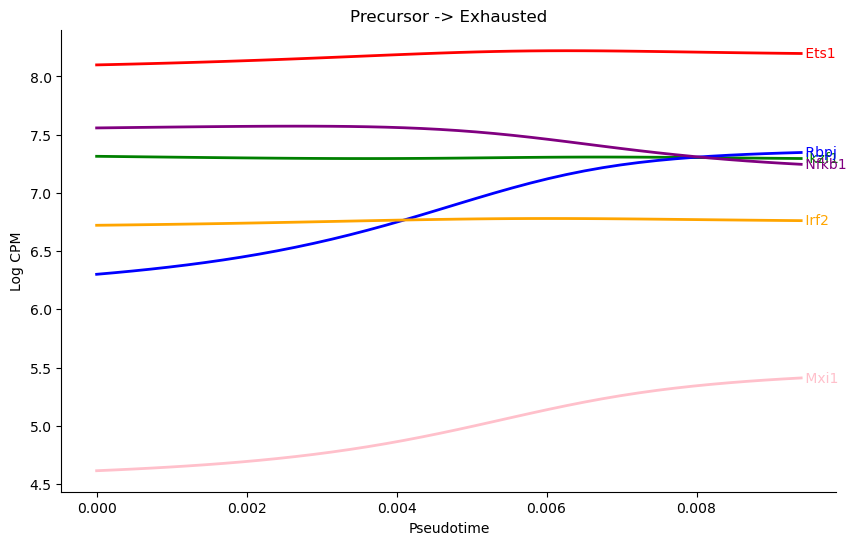

In [33]:
# Plot expression trajectories
fig = plt.figure(figsize=(10, 6))
ax = plt.gca()  # Get current axes

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Highlight specific genes
genes_of_interest = ['Ikzf1','Rbpj','Ets1','Irf2','Nfkb1','Mxi1']
colors = ['green','blue','red','orange','purple','pink']   # Define colors for each gene

for gene, color in zip(genes_of_interest, colors):
    if gene in exp_curves_dy.index:
        line = plt.plot(exp_curves_dx, exp_curves_dy.loc[gene], linewidth=2, color=color)
        # Add label at the end of the line
        plt.text(exp_curves_dx.iloc[-1], exp_curves_dy.loc[gene].iloc[-1], f' {gene}', 
                color=color, 
                verticalalignment='center')

plt.xlabel('Pseudotime')
plt.ylabel('Log CPM')
plt.title('Precursor -> Exhausted')
plt.show()

In [31]:
reg_curves_dy, reg_curves_dx = SmoothedCurvesGRN(dictys_dynamic_object,
    trajectory_range=(0,1),
    num_points=40,
    dist=0.002,
    sparsity=0.01,
    mode="regulation").get_smoothed_curves()

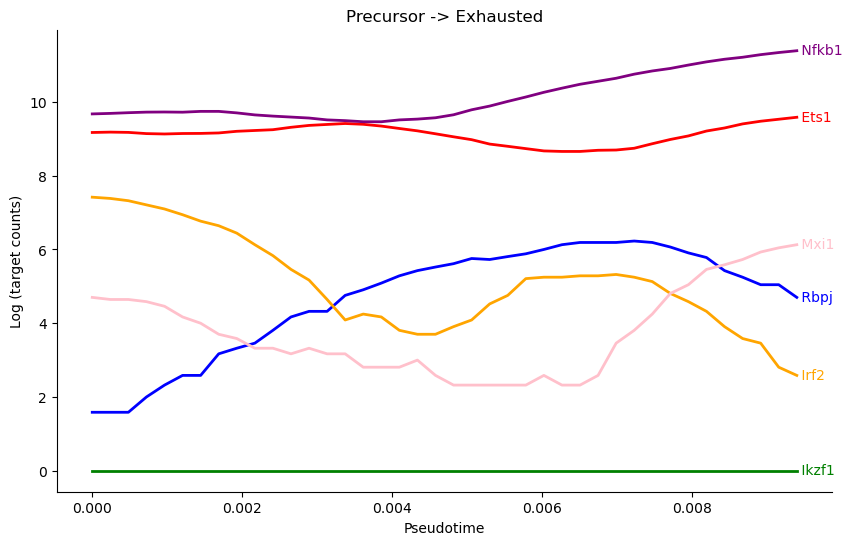

In [32]:
# Plot expression trajectories
fig = plt.figure(figsize=(10, 6))
ax = plt.gca()  # Get current axes

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Highlight specific genes
genes_of_interest = ['Ikzf1','Rbpj','Ets1','Irf2','Nfkb1','Mxi1']
colors = ['green','blue','red','orange','purple','pink']   # Define colors for each gene

for gene, color in zip(genes_of_interest, colors):
    if gene in reg_curves_dy.index:
        line = plt.plot(reg_curves_dx, reg_curves_dy.loc[gene], linewidth=2, color=color)
        # Add label at the end of the line
        plt.text(reg_curves_dx.iloc[-1], reg_curves_dy.loc[gene].iloc[-1], f' {gene}', 
                color=color, 
                verticalalignment='center')

plt.xlabel('Pseudotime')
plt.ylabel('Log (target counts)')
plt.title('Precursor -> Exhausted')
plt.show()

## Episodically enriched TFs

In [7]:
# ETS1 KO
ets1_lf_sig1 = pd.read_csv(f"{config.TCELL_LF_ETS1}/feature_list_Z7.txt", sep='\t')['names'].tolist()
ets1_lf_sig2 = pd.read_csv(f"{config.TCELL_LF_ETS1}/feature_list_Z28.txt", sep='\t')['names'].tolist()
ets1_lf_int1 = pd.read_csv(f"{config.TCELL_LF_ETS1}/feature_list_Z16.txt", sep='\t')['names'].tolist()
ets1_lf_int2 = pd.read_csv(f"{config.TCELL_LF_ETS1}/feature_list_Z26.txt", sep='\t')['names'].tolist()

#create a set of all latent factors
ets1_all_lfs = set(ets1_lf_sig1 + ets1_lf_sig2 + ets1_lf_int1 + ets1_lf_int2)
display(len(ets1_all_lfs))

104

In [8]:
# IKZF1 KO
ikzf1_lf_sig = pd.read_csv(f"{config.TCELL_LF_IKZF1}/feature_list_Z7.txt", sep='\t')['names'].tolist()
ikzf1_lf_int1 = pd.read_csv(f"{config.TCELL_LF_IKZF1}/feature_list_Z18.txt", sep='\t')['names'].tolist()
ikzf1_lf_int2 = pd.read_csv(f"{config.TCELL_LF_IKZF1}/feature_list_Z29.txt", sep='\t')['names'].tolist()

#create a set of all latent factors
ikzf1_all_lfs = set(ikzf1_lf_sig + ikzf1_lf_int1 + ikzf1_lf_int2)
display(len(ikzf1_all_lfs))

109

In [9]:
enrichment_outs = f"{config.TCELL_OUTPUT}/ikzf1"

In [10]:
# time slice is the number of windows in the episode based on the sampled num_points
run_episodic_enrichment(
    episode_idx=1,
    dictys_dynamic_object_path=os.path.join(output_folder, 'dynamic.h5'),
    output_folder=enrichment_outs,
    trajectory_range=(0, 1),
    num_points=24,
    time_slice_start=0,
    time_slice_end=4, # last index is excluded
    lf_genes=ikzf1_all_lfs,
    percentile=98
)

Processing 2,370,323 rows using 16 processes...
Chunk size: 8,000 rows
Direction invariance check: Enabled
Time columns: ['time_0', 'time_1', 'time_2', 'time_3']
Creating index chunks...
Created 297 chunks of indices


Processing chunks: 100%|██████████| 297/297 [02:54<00:00,  1.70it/s]


Processing completed in 174.78 seconds
Sorting results...
Creating result DataFrame...
Processing 956,116 edges using 20 processes...
Chunk size: 30,000 rows
Time columns: ['time_0', 'time_1', 'time_2', 'time_3']
Beta curves shape: (956116, 4)
TF expression shape: (430, 4)
Created 31 chunks
Chunk sizes: [30843, 30843, 30843, 30843, 30843]...


Processing chunks: 100%|██████████| 31/31 [00:02<00:00, 12.74it/s]


Processing completed in 3.01 seconds
Combining results...
Final shape: (956116, 4)


'/ocean/projects/cis240075p/asachan/datasets/B_Cell/T_cell/outs/dictys/rbpj_ntc/output/ikzf1/enrichment_episode_1.csv'

### Viz heatmap of links

In [6]:
#ikzf1-ko lf
ikzf1_d = {'Ep300': ('Capzb', 'Ccdc28b', 'Hdac7', 'Klf2', 'Myl12b', 'Ndufa13', 'Satb1'),
'E2f2': ('Arpc2', 'Bst2', 'Capzb', 'Ccdc28b', 'Cdc42', 'Eif3k', 'Gmfg', 'Ier3', 'Klf2', 'Limd2', 'Myl12b', 'Psmb8', 'Sh3bgrl3'),
'Rad21': ('Arpc2', 'Capzb', 'Cdk17', 'Cox7a2l', 'Eif3k', 'Emb', 'Pglyrp1', 'Rgs2', 'S100a10', 'Stk17b'),
'Klf2': ('Actr3', 'Capzb', 'Dennd4a', 'Gmfg', 'Gpx1', 'Ier3', 'Oaz1', 'Ptms', 'Ptprcap', 'Satb1', 'Tcf7')
}

ikzf1_links = [(tf, target) for tf, targets in ikzf1_d.items() for target in targets]

#ets1-ko lf
ets1_d = {'Nfe2': ('Bhlhe40', 'Fos', 'Fosb', 'Klf6'),
'Ets1': ('Fosb', 'Jun', 'Klf6', 'Nfil3', 'Park7', 'Srebf2', 'Tcf7'),
'Srf': ('Bhlhe40', 'Fosb', 'Jun'),
'E2f2': ('Bhlhe40', 'Fosb', 'Jun', 'Klf6')
}

ets1_links = [(tf, target) for tf, targets in ets1_d.items() for target in targets]

In [13]:
display(ikzf1_links)

[('Ep300', 'Capzb'),
 ('Ep300', 'Ccdc28b'),
 ('Ep300', 'Hdac7'),
 ('Ep300', 'Klf2'),
 ('Ep300', 'Myl12b'),
 ('Ep300', 'Ndufa13'),
 ('Ep300', 'Satb1'),
 ('E2f2', 'Arpc2'),
 ('E2f2', 'Bst2'),
 ('E2f2', 'Capzb'),
 ('E2f2', 'Ccdc28b'),
 ('E2f2', 'Cdc42'),
 ('E2f2', 'Eif3k'),
 ('E2f2', 'Gmfg'),
 ('E2f2', 'Ier3'),
 ('E2f2', 'Klf2'),
 ('E2f2', 'Limd2'),
 ('E2f2', 'Myl12b'),
 ('E2f2', 'Psmb8'),
 ('E2f2', 'Sh3bgrl3'),
 ('Rad21', 'Arpc2'),
 ('Rad21', 'Capzb'),
 ('Rad21', 'Cdk17'),
 ('Rad21', 'Cox7a2l'),
 ('Rad21', 'Eif3k'),
 ('Rad21', 'Emb'),
 ('Rad21', 'Pglyrp1'),
 ('Rad21', 'Rgs2'),
 ('Rad21', 'S100a10'),
 ('Rad21', 'Stk17b'),
 ('Klf2', 'Actr3'),
 ('Klf2', 'Capzb'),
 ('Klf2', 'Dennd4a'),
 ('Klf2', 'Gmfg'),
 ('Klf2', 'Gpx1'),
 ('Klf2', 'Ier3'),
 ('Klf2', 'Oaz1'),
 ('Klf2', 'Ptms'),
 ('Klf2', 'Ptprcap'),
 ('Klf2', 'Satb1'),
 ('Klf2', 'Tcf7')]

In [7]:
pseudotime_object = SmoothedCurvesGRN(dictys_dynamic_object,
    trajectory_range=(0,1),
    num_points=40,
    dist=0.002,
    sparsity=0.01)

In [24]:
beta_curves, dtime = pseudotime_object.get_beta_curves(ets1_links, varname='w_in')

In [25]:
display(beta_curves)

time_0    time_1    time_2    time_3    time_4    time_5  \
TF   Target                                                                
Nfe2 Srebf2   0.072368  0.072125  0.071881  0.071627  0.071352  0.071044   
     Fosb    -0.040723 -0.039216 -0.037468 -0.035450 -0.033129 -0.030468   
     Nfil3    0.018412  0.017029  0.015589  0.014091  0.012530  0.010906   
     Park7   -0.002592 -0.002228 -0.001840 -0.001424 -0.000974 -0.000484   
     Bhlhe40 -0.063118 -0.061359 -0.059354 -0.057089 -0.054547 -0.051713   
     Jun      0.012793  0.012820  0.012896  0.013022  0.013196  0.013414   
     Tcf7    -0.014638 -0.014709 -0.014811 -0.014960 -0.015174 -0.015477   
     Klf6     0.051838  0.048849  0.045686  0.042346  0.038829  0.035138   
     Fos     -0.039632 -0.035246 -0.030513 -0.025409 -0.019914 -0.014009   
E2f2 Srebf2  -0.095872 -0.098135 -0.100136 -0.101797 -0.103030 -0.103734   
     Fosb     0.028460  0.026622  0.024626  0.022487  0.020222  0.017854   
     Nfil3   -0.025345 -0.026241 -0.027270 -0.028441 -0.029759 -0.031228   
     Park7   -0.012221 -0.012014 -0.011610 -0.010975 -0.010076 -0.008876   
     Bhlhe40  0.162598  0.158405  0.153625  0.148203  0.142085  0.135218   
     Jun     -0.036890 -0.036913 -0.036682 -0.036149 -0.035262 -0.033963   
     Tcf7     0.083551  0.084666  0.085650  0.086460  0.087047  0.087354   
     Klf6    -0.033194 -0.035489 -0.037989 -0.040690 -0.043584 -0.046656   
     Fos     -0.095034 -0.094194 -0.093166 -0.091949 -0.090542 -0.088951   
Srf  Srebf2  -0.065873 -0.065292 -0.064686 -0.064044 -0.063352 -0.062597   
     Fosb     0.035159  0.034420  0.033588  0.032649  0.031589  0.030391   
     Nfil3   -0.012747 -0.013006 -0.013270 -0.013535 -0.013798 -0.014051   
     Park7   -0.043673 -0.044435 -0.045222 -0.046020 -0.046814 -0.047580   
     Bhlhe40  0.016627  0.017018  0.017401  0.017769  0.018112  0.018420   
     Jun     -0.012082 -0.012109 -0.012119 -0.012106 -0.012064 -0.011985   
     Tcf7     0.037868  0.037043  0.036207  0.035360  0.034503  0.033638   
     Klf6    -0.012001 -0.012911 -0.013857 -0.014845 -0.015877 -0.016960   
     Fos      0.018118  0.016535  0.014869  0.013122  0.011299  0.009404   
Ets1 Srebf2   0.048928  0.048590  0.048302  0.048063  0.047869  0.047714   
     Fosb    -0.028365 -0.027392 -0.026420 -0.025452 -0.024491 -0.023539   
     Nfil3    0.023598  0.021768  0.019861  0.017883  0.015840  0.013739   
     Park7    0.034150  0.034497  0.034851  0.035216  0.035593  0.035985   
     Bhlhe40  0.060356  0.063217  0.066349  0.069780  0.073541  0.077658   
     Jun      0.051245  0.051065  0.050788  0.050396  0.049874  0.049201   
     Tcf7    -0.011795 -0.010646 -0.009559 -0.008549 -0.007636 -0.006839   
     Klf6     0.003560  0.003871  0.004091  0.004199  0.004176  0.003995   
     Fos     -0.038782 -0.036930 -0.035117 -0.033361 -0.031681 -0.030100   

                time_6    time_7    time_8    time_9  ...   time_30   time_31  \
TF   Target                                           ...                       
Nfe2 Srebf2   0.070686  0.070262  0.069754  0.069142  ...  0.068014  0.068716   
     Fosb    -0.027429 -0.023972 -0.020056 -0.015641  ...  0.086464  0.083075   
     Nfil3    0.009218  0.007467  0.005657  0.003795  ...  0.015612  0.022024   
     Park7    0.000054  0.000650  0.001316  0.002064  ...  0.033382  0.031289   
     Bhlhe40 -0.048577 -0.045126 -0.041354 -0.037258  ...  0.087974  0.091819   
     Jun      0.013670  0.013953  0.014253  0.014554  ...  0.068591  0.078911   
     Tcf7    -0.015893 -0.016450 -0.017178 -0.018111  ... -0.067715 -0.068370   
     Klf6     0.031285  0.027287  0.023172  0.018980  ...  0.044316  0.048557   
     Fos     -0.007681 -0.000925  0.006253  0.013832  ...  0.031089  0.022864   
E2f2 Srebf2  -0.103800 -0.103111 -0.101542 -0.098969  ...  0.067932  0.068654   
     Fosb     0.015415  0.012944  0.010490  0.008111  ...  0.056800  0.058803   
     Nfil3   -0.032847 -0.034610 -0.036504 -0.038505  ...  0.012296  0.016

In [26]:
# get the expression curves of the TFs in the specified links
tf_expression, _ = pseudotime_object.get_smoothed_curves(mode='tf_expression')
regulon_tf_expression = tf_expression.loc[beta_curves.index.get_level_values(0).unique()]

In [27]:
force_curves = pseudotime_object.calculate_force_curves(beta_curves, regulon_tf_expression)

In [28]:
display(force_curves)

time_0    time_1    time_2    time_3    time_4    time_5  \
TF   Target                                                                
Nfe2 Srebf2   0.245258  0.246709  0.248151  0.249559  0.250905  0.252156   
     Fosb    -0.191063 -0.189348 -0.186996 -0.183872 -0.179806 -0.174578   
     Nfil3    0.135350  0.131803  0.127773  0.123169  0.117876  0.111742   
     Park7   -0.057764 -0.054487 -0.050511 -0.045515 -0.038869 -0.028885   
     Bhlhe40 -0.231115 -0.229982 -0.228349 -0.226143 -0.223282 -0.219670   
     Jun      0.115553  0.116512  0.117670  0.119022  0.120557  0.122252   
     Tcf7    -0.122516 -0.123681 -0.124961 -0.126411 -0.128095 -0.130088   
     Klf6     0.212175  0.208300  0.203814  0.198628  0.192640  0.185732   
     Fos     -0.188822 -0.180771 -0.171041 -0.159113 -0.144147 -0.124578   
E2f2 Srebf2  -0.726493 -0.734291 -0.741166 -0.746900 -0.751241 -0.753897   
     Fosb     0.428708  0.416678  0.403040  0.387661  0.370400  0.351099   
     Nfil3   -0.407658 -0.414080 -0.421292 -0.429294 -0.438074 -0.447593   
     Park7   -0.296972 -0.294942 -0.290751 -0.283899 -0.273708 -0.259190   
     Bhlhe40  0.913838  0.904018  0.892560  0.879235  0.863776  0.845874   
     Jun     -0.479836 -0.480225 -0.479184 -0.476418 -0.471572 -0.464214   
     Tcf7     0.684364  0.688690  0.692535  0.695763  0.698208  0.699677   
     Klf6    -0.458334 -0.472093 -0.486525 -0.501539 -0.517025 -0.532853   
     Fos     -0.723728 -0.721334 -0.718303 -0.714612 -0.710248 -0.705205   
Srf  Srebf2  -0.582730 -0.580498 -0.578148 -0.575633 -0.572900 -0.569886   
     Fosb     0.443659  0.439587  0.434935  0.429602  0.423469  0.416393   
     Nfil3   -0.285556 -0.288063 -0.290584 -0.293086 -0.295524 -0.297848   
     Park7   -0.487469 -0.491148 -0.494904 -0.498669 -0.502362 -0.505888   
     Bhlhe40  0.320485  0.323737  0.326880  0.329856  0.332595  0.335017   
     Jun     -0.278987 -0.279258 -0.279355 -0.279218 -0.278781 -0.277975   
     Tcf7     0.458193  0.453834  0.449351  0.444744  0.440013  0.435161   
     Klf6    -0.278171 -0.287145 -0.296101 -0.305076 -0.314102 -0.323211   
     Fos      0.332662  0.319714  0.305301  0.289167  0.270963  0.250186   
Ets1 Srebf2   0.668979  0.667094  0.665510  0.664220  0.663204  0.662427   
     Fosb    -0.527940 -0.520093 -0.512100 -0.503972 -0.495726 -0.487381   
     Nfil3    0.487391  0.470688  0.452414  0.432357  0.410251  0.385755   
     Park7    0.572257  0.574880  0.577554  0.580293  0.583115  0.586037   
     Bhlhe40  0.732832  0.747864  0.763886  0.780966  0.799154  0.818480   
     Jun      0.682556  0.681647  0.680172  0.678034  0.675123  0.671316   
     Tcf7    -0.360645 -0.345013 -0.329307 -0.313788 -0.298827 -0.284936   
     Klf6     0.214347  0.222346  0.227785  0.230441  0.229922  0.225613   
     Fos     -0.604753 -0.592150 -0.579465 -0.566818 -0.554364 -0.542305   

                time_6    time_7    time_8    time_9  ...   time_30   time_31  \
TF   Target                                           ...                       
Nfe2 Srebf2   0.253271  0.254204  0.254905  0.255318  ...  0.240247  0.241001   
     Fosb    -0.167895 -0.159353 -0.148348 -0.133893  ...  0.266642  0.261704   
     Nfil3    0.104559  0.096019  0.085618  0.072386  ...  0.126789  0.147032   
     Park7    0.011245  0.033268  0.045447  0.055566  ...  0.176369  0.171252   
     Bhlhe40 -0.215197 -0.209734 -0.203129 -0.195193  ...  0.268654  0.273329   
     Jun      0.124074  0.125976  0.127898  0.129770  ...  0.241130  0.255925   
     Tcf7    -0.132466 -0.135310 -0.138698 -0.142694  ... -0.239788 -0.240474   
     Klf6     0.177765  0.168574  0.157952  0.145629  ...  0.199464  0.207265   
     Fos     -0.096598 -0.038773  0.089423  0.126934  ...  0.171002  0.149441   
E2f2 Srebf2  -0.754535 -0.752776 -0.748187 -0.740277  ...  0.620081  0.622131   
     Fosb     0.329588  0.305678  0.279157  0.249782  ...  0.573711  0.581659   
     Nfil3   -0.457788 -0.468563 -0.479789 -0.491292  ...  0.295172  0.332

In [29]:
# subset force curves to links
beta_curves_plotting = beta_curves.loc[ets1_links]
force_curves_plotting = force_curves.loc[ets1_links]

In [30]:
display(beta_curves_plotting)
display(force_curves_plotting)

time_0    time_1    time_2    time_3    time_4    time_5  \
TF   Target                                                                
Nfe2 Bhlhe40 -0.063118 -0.061359 -0.059354 -0.057089 -0.054547 -0.051713   
     Fos     -0.039632 -0.035246 -0.030513 -0.025409 -0.019914 -0.014009   
     Fosb    -0.040723 -0.039216 -0.037468 -0.035450 -0.033129 -0.030468   
     Klf6     0.051838  0.048849  0.045686  0.042346  0.038829  0.035138   
Ets1 Fosb    -0.028365 -0.027392 -0.026420 -0.025452 -0.024491 -0.023539   
     Jun      0.051245  0.051065  0.050788  0.050396  0.049874  0.049201   
     Klf6     0.003560  0.003871  0.004091  0.004199  0.004176  0.003995   
     Nfil3    0.023598  0.021768  0.019861  0.017883  0.015840  0.013739   
     Park7    0.034150  0.034497  0.034851  0.035216  0.035593  0.035985   
     Srebf2   0.048928  0.048590  0.048302  0.048063  0.047869  0.047714   
     Tcf7    -0.011795 -0.010646 -0.009559 -0.008549 -0.007636 -0.006839   
Srf  Bhlhe40  0.016627  0.017018  0.017401  0.017769  0.018112  0.018420   
     Fosb     0.035159  0.034420  0.033588  0.032649  0.031589  0.030391   
     Jun     -0.012082 -0.012109 -0.012119 -0.012106 -0.012064 -0.011985   
E2f2 Bhlhe40  0.162598  0.158405  0.153625  0.148203  0.142085  0.135218   
     Fosb     0.028460  0.026622  0.024626  0.022487  0.020222  0.017854   
     Jun     -0.036890 -0.036913 -0.036682 -0.036149 -0.035262 -0.033963   
     Klf6    -0.033194 -0.035489 -0.037989 -0.040690 -0.043584 -0.046656   

                time_6    time_7    time_8    time_9  ...   time_30   time_31  \
TF   Target                                           ...                       
Nfe2 Bhlhe40 -0.048577 -0.045126 -0.041354 -0.037258  ...  0.087974  0.091819   
     Fos     -0.007681 -0.000925  0.006253  0.013832  ...  0.031089  0.022864   
     Fosb    -0.027429 -0.023972 -0.020056 -0.015641  ...  0.086464  0.083075   
     Klf6     0.031285  0.027287  0.023172  0.018980  ...  0.044316  0.048557   
Ets1 Fosb    -0.022599 -0.021674 -0.020766 -0.019874  ... -0.007604 -0.011866   
     Jun      0.048360  0.047328  0.046085  0.044607  ... -0.029866 -0.030437   
     Klf6     0.003633  0.003062  0.002253  0.001181  ... -0.027402 -0.027514   
     Nfil3    0.011592  0.009415  0.007226  0.005049  ...  0.026710  0.029540   
     Park7    0.036396  0.036828  0.037285  0.037772  ...  0.091336  0.098925   
     Srebf2   0.047589  0.047481  0.047377  0.047258  ...  0.064436  0.066921   
     Tcf7    -0.006183 -0.005690 -0.005387 -0.005298  ...  0.002595  0.007305   
Srf  Bhlhe40  0.018680  0.018877  0.018996  0.019021  ...  0.184366  0.218215   
     Fosb     0.029037  0.027507  0.025780  0.023834  ...  0.005636  0.013595   
     Jun     -0.011864 -0.011694 -0.011470 -0.011191  ... -0.033999 -0.034801   
E2f2 Bhlhe40  0.127553  0.119046  0.109669  0.099410  ...  0.026303  0.040267   
     Fosb     0.015415  0.012944  0.010490  0.008111  ...  0.056800  0.058803   
     Jun     -0.032194 -0.029893 -0.027003 -0.023469  ...  0.014980  0.004483   
     Klf6    -0.049883 -0.053229 -0.056648 -0.060078  ...  0.035775  0.043950   

               time_32   time_33   time_34   time_35   time_36   time_37  \
TF   Target                                                                
Nfe2 Bhlhe40  0.094954  0.097389  0.099153  0.100299  0.100890  0.100997   
     Fos      0.015651  0.009589  0.004736  0.001080 -0.001440 -0.002918   
     Fosb     0.079437  0.075751  0.072173  0.068819  0.065763  0.063048   
     Klf6     0.052257  0.055466  0.058258  0.060710  0.062899  0.064893   
Ets1 Fosb    -0.017041 -0.023018 -0.029662 -0.036829 -0.044373 -0.052157   
     Jun     -0.030301 -0.029524 -0.028188 -0.026382 -0.024195 -0.021714   
     Klf6    -0.028284 -0.029769 -0.031975 -0.034869 -0.038386 -0.042444   
     Nfil3    0.031756  0.033306  0.034174  0.034370  0.033933  0.032914   
     Park7    0.106820  0.114901  0.123054  0.131174  0.139174  0.146981   
     Srebf2   0.068768  0.069882  0.07

time_0    time_1    time_2    time_3    time_4    time_5  \
TF   Target                                                                
Nfe2 Bhlhe40 -0.231115 -0.229982 -0.228349 -0.226143 -0.223282 -0.219670   
     Fos     -0.188822 -0.180771 -0.171041 -0.159113 -0.144147 -0.124578   
     Fosb    -0.191063 -0.189348 -0.186996 -0.183872 -0.179806 -0.174578   
     Klf6     0.212175  0.208300  0.203814  0.198628  0.192640  0.185732   
Ets1 Fosb    -0.527940 -0.520093 -0.512100 -0.503972 -0.495726 -0.487381   
     Jun      0.682556  0.681647  0.680172  0.678034  0.675123  0.671316   
     Klf6     0.214347  0.222346  0.227785  0.230441  0.229922  0.225613   
     Nfil3    0.487391  0.470688  0.452414  0.432357  0.410251  0.385755   
     Park7    0.572257  0.574880  0.577554  0.580293  0.583115  0.586037   
     Srebf2   0.668979  0.667094  0.665510  0.664220  0.663204  0.662427   
     Tcf7    -0.360645 -0.345013 -0.329307 -0.313788 -0.298827 -0.284936   
Srf  Bhlhe40  0.320485  0.323737  0.326880  0.329856  0.332595  0.335017   
     Fosb     0.443659  0.439587  0.434935  0.429602  0.423469  0.416393   
     Jun     -0.278987 -0.279258 -0.279355 -0.279218 -0.278781 -0.277975   
E2f2 Bhlhe40  0.913838  0.904018  0.892560  0.879235  0.863776  0.845874   
     Fosb     0.428708  0.416678  0.403040  0.387661  0.370400  0.351099   
     Jun     -0.479836 -0.480225 -0.479184 -0.476418 -0.471572 -0.464214   
     Klf6    -0.458334 -0.472093 -0.486525 -0.501539 -0.517025 -0.532853   

                time_6    time_7    time_8    time_9  ...   time_30   time_31  \
TF   Target                                           ...                       
Nfe2 Bhlhe40 -0.215197 -0.209734 -0.203129 -0.195193  ...  0.268654  0.273329   
     Fos     -0.096598 -0.038773  0.089423  0.126934  ...  0.171002  0.149441   
     Fosb    -0.167895 -0.159353 -0.148348 -0.133893  ...  0.266642  0.261704   
     Klf6     0.177765  0.168574  0.157952  0.145629  ...  0.199464  0.207265   
Ets1 Fosb    -0.478954 -0.470465 -0.461925 -0.453333  ... -0.299908 -0.363801   
     Jun      0.666472  0.660433  0.653022  0.644034  ... -0.543268 -0.547691   
     Klf6     0.216546  0.201088  0.176069  0.133034  ... -0.523329 -0.524195   
     Nfil3    0.358406  0.327530  0.292054  0.250020  ...  0.517544  0.540621   
     Park7    0.589079  0.592263  0.595613  0.599152  ...  0.882771  0.913804   
     Srebf2   0.661836  0.661362  0.660913  0.660382  ...  0.758658  0.771142   
     Tcf7    -0.272784 -0.263196 -0.257083 -0.255304  ...  0.188018  0.294693   
Srf  Bhlhe40  0.337031  0.338534  0.339415  0.339557  ...  0.913393  0.983490   
     Fosb     0.408199  0.398673  0.387552  0.374509  ...  0.200828  0.294595   
     Jun     -0.276727 -0.274970 -0.272639 -0.269688  ... -0.438319 -0.443109   
E2f2 Bhlhe40  0.825173  0.801254  0.773627  0.741708  ...  0.410670  0.493458   
     Fosb     0.329588  0.305678  0.279157  0.249782  ...  0.573711  0.581659   
     Jun     -0.453809 -0.439675 -0.420909 -0.396238  ...  0.321596  0.190195   
     Klf6    -0.548866 -0.564879 -0.580676 -0.596000  ...  0.469355  0.512573   

               time_32   time_33   time_34   time_35   time_36   time_37  \
TF   Target                                                                
Nfe2 Bhlhe40  0.277233  0.280397  0.282855  0.284650  0.285835  0.286466   
     Fos      0.126707  0.102460  0.075491  0.039782 -0.045141 -0.061461   
     Fosb     0.256561  0.251409  0.246411  0.241694  0.237353  0.233453   
     Klf6     0.213895  0.219582  0.224523  0.228886  0.232807  0.236396   
Ets1 Fosb    -0.425676 -0.484991 -0.541394 -0.594674 -0.644728 -0.691535   
     Jun     -0.546560 -0.540364 -0.529541 -0.514465 -0.495434 -0.472645   
     Klf6    -0.530451 -0.542302 -0.559335 -0.580714 -0.605399 -0.632338   
     Nfil3    0.557808  0.569405  0.575727  0.577096  0.573828  0.566224   
     Park7    0.944677  0.974954  1.004290  1.032430  1.059198  1.084489   
     Srebf2   0.780222  0.785587  0.78

In [31]:
# expand the tf expression to beta_curves index 0 order
regulon_tf_expression = regulon_tf_expression.reindex(beta_curves_plotting.index.get_level_values(0))

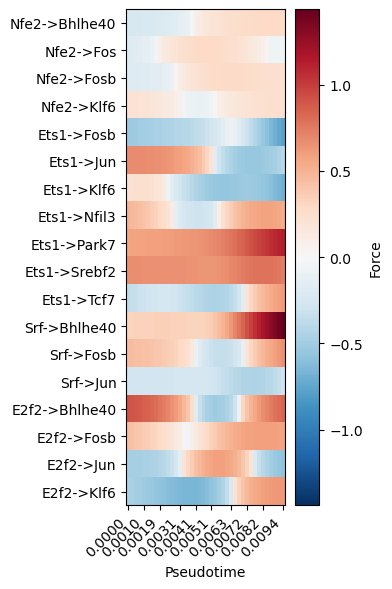

In [32]:
# row_scaling = {
#     ('NFKB1', 'AFF3'): 0.4  # Scale this GC link to x% of its original values
# }

df_plot = force_curves_plotting

force_df_for_cluster, reg_labels, dtime, fig = plot_force_heatmap_with_clustering(
    force_df=df_plot,
    dtime=dtime,
    regulations=ets1_links,
    cmap='RdBu_r',
    vmax=None,
    figsize= (4, 6),
    plot_figure=True,
    perform_clustering=False,
    row_scaling=None 
)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{config.FIGURES_SUPPL}/ets1_ko_activity.pdf", 
            bbox_inches='tight', 
            dpi=300,
            format='pdf')
plt.show()